# 🌾 AgriSmart — NB3: U-Net Training (MobileNetV2 Encoder)

**Objectif :** Entraîner un modèle de segmentation sémantique pixel-à-pixel
pour classifier 6 types de couverture terrestre sur l'image Béja.

## Pourquoi U-Net ?
U-Net est l'architecture standard pour la segmentation d'images satellitaires.
Sa structure en 'U' combine :
- **Encoder** (partie descendante) : extrait les features à différentes échelles
- **Decoder** (partie montante) : reconstruit la carte pixel par pixel
- **Skip connections** : relient encoder↔decoder pour préserver les détails fins
  (contours de champs, bordures routes)

## Pourquoi MobileNetV2 comme encoder ?
- Conçu pour les machines à ressources limitées (4GB VRAM RTX 3050 laptop)
- 3.4M paramètres vs 25M pour ResNet50 → 7× plus léger
- Pre-trained sur ImageNet → transfer learning = convergence plus rapide
- Validé pour la télédetection (Brügger et al. 2021)

## Adaptations pour RTX 3050 laptop (4GB VRAM)
- Batch size = 4 (compromise entre stabilité et mémoire)
- Mixed precision float16 → réduit VRAM de 40%
- Epochs = 20 (conforme au rapport, ~2h d'entraînement)
- Gradient accumulation si besoin

---
## 📦 Part 1 : Installation

In [9]:
!pip install torch torchvision segmentation-models-pytorch albumentations -q
print('✅ Packages OK')

✅ Packages OK


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import warnings, gc
warnings.filterwarnings('ignore')

# --- CHEMINS ───────────────────────────────────────────────────────────────
PATCHES_DIR = Path('/content/drive/MyDrive/patches') # Changed path to Google Drive
MODEL_DIR   = PATCHES_DIR.parent / 'models' # Save models to Google Drive
MODEL_DIR.mkdir(exist_ok=True)

# --- HYPERPARAMÈTRES ───────────────────────────────────────────────────────
N_CLASSES   = 6
N_CHANNELS  = 9      # 4 bandes + 5 indices
BATCH_SIZE  = 4      # adapté RTX 3050 4GB VRAM
EPOCHS      = 20     # conforme rapport section 4.2 étape 7
LR          = 1e-4
PATCH_SIZE  = 128

# --- DEVICE ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device : {device}')
if torch.cuda.is_available():
    print(f'   GPU     : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# Mixed precision (réduit VRAM de ~40%, accélère sur RTX)
USE_AMP = torch.cuda.is_available()
scaler  = torch.cuda.amp.GradScaler() if USE_AMP else None
print(f'   AMP (float16) : {USE_AMP}')

🖥️  Device : cuda
   GPU     : Tesla T4
   VRAM    : 15.6 GB
   AMP (float16) : True


---
## 📂 Part 2 : Dataset PyTorch avec augmentation live

L'augmentation est appliquée **à la volée** pendant l'entraînement
(pas pré-calculée) → économise de l'espace disque.

In [12]:
class BejaPatchDataset(Dataset):
    """
    Dataset PyTorch pour les patches Béja.
    - Charge les fichiers .npy à la demande (lazy loading)
    - Applique l'augmentation uniquement sur le train set
    """
    def __init__(self, patch_ids, patches_dir, augment=False):
        self.ids      = patch_ids
        self.dir      = Path(patches_dir)
        self.augment  = augment

        # Augmentations albumentations (compatible multi-canaux)
        self.aug_transform = A.Compose([
            A.RandomRotate90(p=0.5),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.GaussNoise(var_limit=(0.01, 0.05), p=0.3),
            A.RandomBrightnessContrast(brightness_limit=0.1,
                                       contrast_limit=0.1, p=0.2),
        ])

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        pid = self.ids[idx]
        img = np.load(self.dir / 'images' / f'patch_{pid:05d}.npy').astype(np.float32)
        lbl = np.load(self.dir / 'labels' / f'patch_{pid:05d}.npy').astype(np.int64)

          # ✅ AJOUT : remplacer NaN et Inf par 0
        img = np.nan_to_num(img, nan=0.0, posinf=3.0, neginf=-3.0)

    # ✅ AJOUT : s'assurer que les labels sont dans [0, N_CLASSES-1]
        lbl = np.clip(lbl, 0, 5)

        if self.augment:
            aug = self.aug_transform(image=img, mask=lbl)
            img, lbl = aug['image'], aug['mask']

        # (H,W,C) → (C,H,W) pour PyTorch
        img = torch.from_numpy(img.transpose(2, 0, 1))
        lbl = torch.from_numpy(lbl)
        return img, lbl


# Chargement des splits
train_ids = np.load(PATCHES_DIR / 'split_train.npy').tolist()
val_ids   = np.load(PATCHES_DIR / 'split_val.npy').tolist()

train_ds = BejaPatchDataset(train_ids, PATCHES_DIR, augment=True)
val_ds   = BejaPatchDataset(val_ids,   PATCHES_DIR, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=USE_AMP)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=USE_AMP)

print(f'✅ Datasets créés')
print(f'   Train : {len(train_ds):,} patches → {len(train_loader):,} batches')
print(f'   Val   : {len(val_ds):,} patches  → {len(val_loader):,} batches')

✅ Datasets créés
   Train : 4,075 patches → 1,019 batches
   Val   : 576 patches  → 144 batches


---
## 🏗️ Part 3 : Architecture U-Net + MobileNetV2

On utilise `segmentation_models_pytorch` (smp) qui fournit U-Net
avec encodeurs pré-entraînés. On adapte le premier layer pour accepter
9 canaux (au lieu de 3 RGB standard).

In [13]:
# Construction du modèle U-Net + MobileNetV2
model = smp.Unet(
    encoder_name    = 'mobilenet_v2',   # encoder léger pour 4GB VRAM
    encoder_weights = 'imagenet',        # transfer learning depuis ImageNet
    in_channels     = N_CHANNELS,        # 9 bandes (adaptation auto du 1er layer)
    classes         = N_CLASSES,         # 6 classes de couverture terrestre
    activation      = None               # on applique softmax dans le loss
)
model = model.to(device)

# Compter les paramètres
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'📐 Modèle U-Net (MobileNetV2 encoder)')
print(f'   Paramètres totaux     : {total_params:,}')
print(f'   Paramètres entraînable: {train_params:,}')

# Estimation VRAM
param_mb   = total_params * 4 / 1e6  # float32
param_fp16 = param_mb / 2             # float16
print(f'   VRAM modèle (fp32)    : ~{param_mb:.0f} MB')
print(f'   VRAM modèle (fp16 AMP): ~{param_fp16:.0f} MB')

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

📐 Modèle U-Net (MobileNetV2 encoder)
   Paramètres totaux     : 6,631,398
   Paramètres entraînable: 6,631,398
   VRAM modèle (fp32)    : ~27 MB
   VRAM modèle (fp16 AMP): ~13 MB


---
## ⚖️ Part 4 : Loss Function (Weighted Cross-Entropy + Dice)

**Weighted Cross-Entropy** : pénalise plus les erreurs sur les classes rares
(Eau/Roche 5.2% et Très Dense 4.7%) — rapport section 3.3.

**Dice Loss** : optimise directement l'IoU (métrique cible du rapport section 7.2).

**Combinaison** : `Loss = 0.5 × CrossEntropy + 0.5 × Dice`

In [14]:
# Chargement des poids calculés par NB2
class_weights = np.load(PATCHES_DIR / 'class_weights.npy').astype(np.float32)
weights_tensor = torch.tensor(class_weights).to(device)

print('⚖️ Poids classes (weighted loss) :')
class_names = ['Eau/Roche', 'Sol nu', 'Vég. sparse', 'Vég. mod.', 'Vég. dense', 'Très dense']
for name, w in zip(class_names, class_weights):
    print(f'   {name:15} : {w:.3f}')

# Cross-entropy avec poids
ce_loss_fn = nn.CrossEntropyLoss(weight=weights_tensor)

# Dice Loss via smp
dice_loss_fn = smp.losses.DiceLoss(mode='multiclass')

def combined_loss(pred, target):
    """0.5 * CE + 0.5 * Dice — balance précision globale + IoU par classe"""
    return 0.5 * ce_loss_fn(pred, target) + 0.5 * dice_loss_fn(pred, target)

# Optimiseur Adam avec learning rate schedule
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print('\n✅ Loss + optimiseur configurés')

⚖️ Poids classes (weighted loss) :
   Eau/Roche       : 4.500
   Sol nu          : 0.044
   Vég. sparse     : 0.940
   Vég. mod.       : 0.248
   Vég. dense      : 0.131
   Très dense      : 0.136

✅ Loss + optimiseur configurés


---
## 🚀 Part 5 : Boucle d'entraînement (20 epochs)

Stratégie adaptée RTX 3050 :
- Mixed precision (AMP) : float16 sur GPU, float32 pour les gradients
- Early stopping si val_loss ne s'améliore pas pendant 5 epochs
- Sauvegarde du meilleur modèle

In [15]:
def compute_pixel_accuracy(pred_logits, targets):
    """Accuracy pixel par pixel (métrique principale rapport 7.2)"""
    preds = pred_logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


def train_one_epoch(model, loader, optimizer, scaler, device, use_amp):
    model.train()
    total_loss, total_acc, n = 0., 0., 0

    for imgs, lbls in loader:
        imgs = imgs.to(device)
        lbls = lbls.to(device).long() # Explicitly cast labels to long

         # ✅ AJOUT : skip le batch si NaN détecté
        if torch.isnan(imgs).any() or torch.isinf(imgs).any():
             continue

        optimizer.zero_grad()

        if use_amp:
            with torch.cuda.amp.autocast():
                preds = model(imgs)
                loss  = combined_loss(preds, lbls)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # ✅ AJOUT
            scaler.step(optimizer)
            scaler.update()
        else:
            preds = model(imgs)
            loss  = combined_loss(preds, lbls)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # ✅ AJOUT
            optimizer.step()

        total_loss += loss.item()
        total_acc  += compute_pixel_accuracy(preds.detach(), lbls)
        n += 1

    return total_loss / n, total_acc / n


def validate(model, loader, device, use_amp):
    model.eval()
    total_loss, total_acc, n = 0., 0., 0

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            lbls = lbls.to(device).long() # Explicitly cast labels to long

            if use_amp:
                with torch.cuda.amp.autocast():
                    preds = model(imgs)
                    loss  = combined_loss(preds, lbls)
            else:
                preds = model(imgs)
                loss  = combined_loss(preds, lbls)

            total_loss += loss.item()
            total_acc  += compute_pixel_accuracy(preds, lbls)
            n += 1

    return total_loss / n, total_acc / n


# ─── BOUCLE PRINCIPALE ─────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
patience      = 5
patience_cnt  = 0

print(f'🚀 Entraînement U-Net : {EPOCHS} epochs, batch={BATCH_SIZE}, device={device}')
print('=' * 70)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, scaler, device, USE_AMP)
    vl_loss, vl_acc = validate(model, val_loader, device, USE_AMP)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    # Sauvegarde du meilleur modèle
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_cnt  = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': best_val_loss,
            'val_acc': vl_acc,
        }, MODEL_DIR / 'best_unet_beja.pth')
        best_marker = ' ← BEST'
    else:
        patience_cnt += 1
        best_marker = ''

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train loss={tr_loss:.4f} acc={tr_acc:.3f} | '
          f'Val loss={vl_loss:.4f} acc={vl_acc:.3f} | '
          f'LR={scheduler.get_last_lr()[0]:.2e}{best_marker}')

    # Early stopping
    if patience_cnt >= patience:
        print(f'\n⏹️  Early stopping (patience={patience})')
        break

print('\n✅ Entraînement terminé')
print(f'   Meilleur val_loss : {best_val_loss:.4f}')

🚀 Entraînement U-Net : 20 epochs, batch=4, device=cuda
Epoch 01/20 | Train loss=0.8073 acc=0.723 | Val loss=0.3829 acc=0.891 | LR=9.94e-05 ← BEST
Epoch 02/20 | Train loss=0.5729 acc=0.809 | Val loss=0.3878 acc=0.876 | LR=9.76e-05
Epoch 03/20 | Train loss=0.4573 acc=0.848 | Val loss=0.3550 acc=0.893 | LR=9.46e-05 ← BEST
Epoch 04/20 | Train loss=0.4216 acc=0.865 | Val loss=0.2489 acc=0.929 | LR=9.05e-05 ← BEST
Epoch 05/20 | Train loss=0.4030 acc=0.870 | Val loss=0.2478 acc=0.936 | LR=8.55e-05 ← BEST
Epoch 06/20 | Train loss=0.3644 acc=0.880 | Val loss=0.2324 acc=0.937 | LR=7.96e-05 ← BEST
Epoch 07/20 | Train loss=0.3506 acc=0.887 | Val loss=0.2674 acc=0.918 | LR=7.30e-05
Epoch 08/20 | Train loss=0.3346 acc=0.891 | Val loss=0.2318 acc=0.940 | LR=6.58e-05 ← BEST
Epoch 09/20 | Train loss=0.3237 acc=0.894 | Val loss=0.2706 acc=0.919 | LR=5.82e-05
Epoch 10/20 | Train loss=0.3405 acc=0.895 | Val loss=0.2206 acc=0.942 | LR=5.05e-05 ← BEST
Epoch 11/20 | Train loss=0.3259 acc=0.895 | Val loss=0.2

---
## 📈 Part 6 : Courbes d'apprentissage

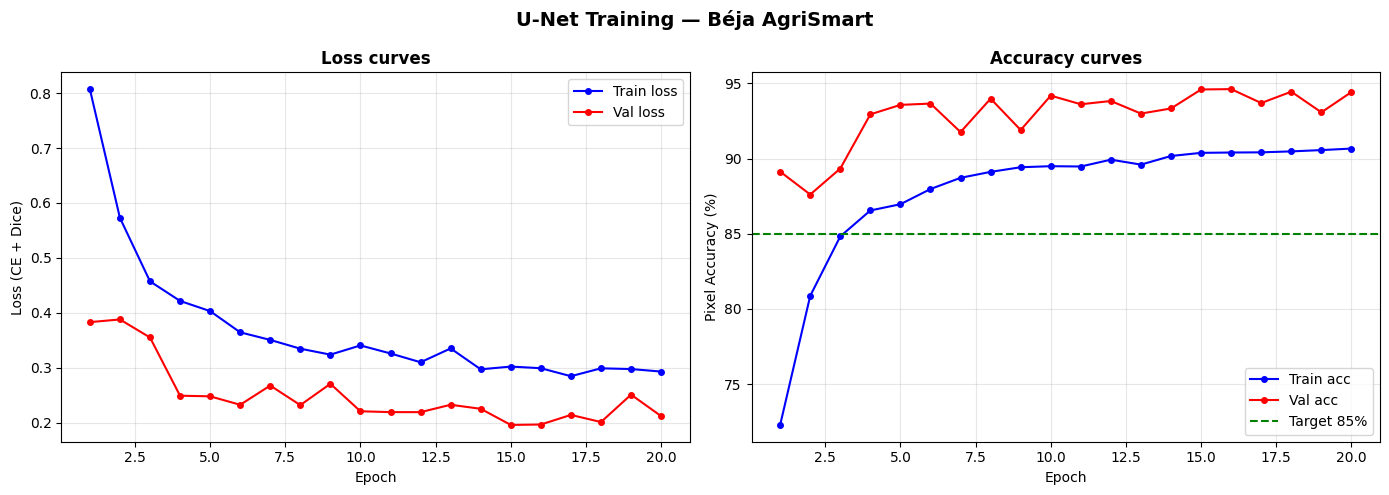


📊 Résultats finaux :
   Train accuracy : 90.7%
   Val accuracy   : 94.4%
   (Target rapport : ≥ 85%)


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_x = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_x, history['train_loss'], 'b-o', label='Train loss', markersize=4)
ax1.plot(epochs_x, history['val_loss'],   'r-o', label='Val loss',   markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (CE + Dice)')
ax1.set_title('Loss curves', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_x, [a*100 for a in history['train_acc']], 'b-o', label='Train acc', markersize=4)
ax2.plot(epochs_x, [a*100 for a in history['val_acc']],   'r-o', label='Val acc',   markersize=4)
ax2.axhline(y=85, color='g', linestyle='--', label='Target 85%')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Pixel Accuracy (%)')
ax2.set_title('Accuracy curves', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('U-Net Training — Béja AgriSmart', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'NB3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Résultats finaux :')
print(f'   Train accuracy : {history["train_acc"][-1]*100:.1f}%')
print(f'   Val accuracy   : {history["val_acc"][-1]*100:.1f}%')
print(f'   (Target rapport : ≥ 85%)')

---
## 🔍 Part 7 : Prédictions visuelles sur quelques patches val

✅ Meilleur modèle chargé (epoch 15, val_loss=0.1957)


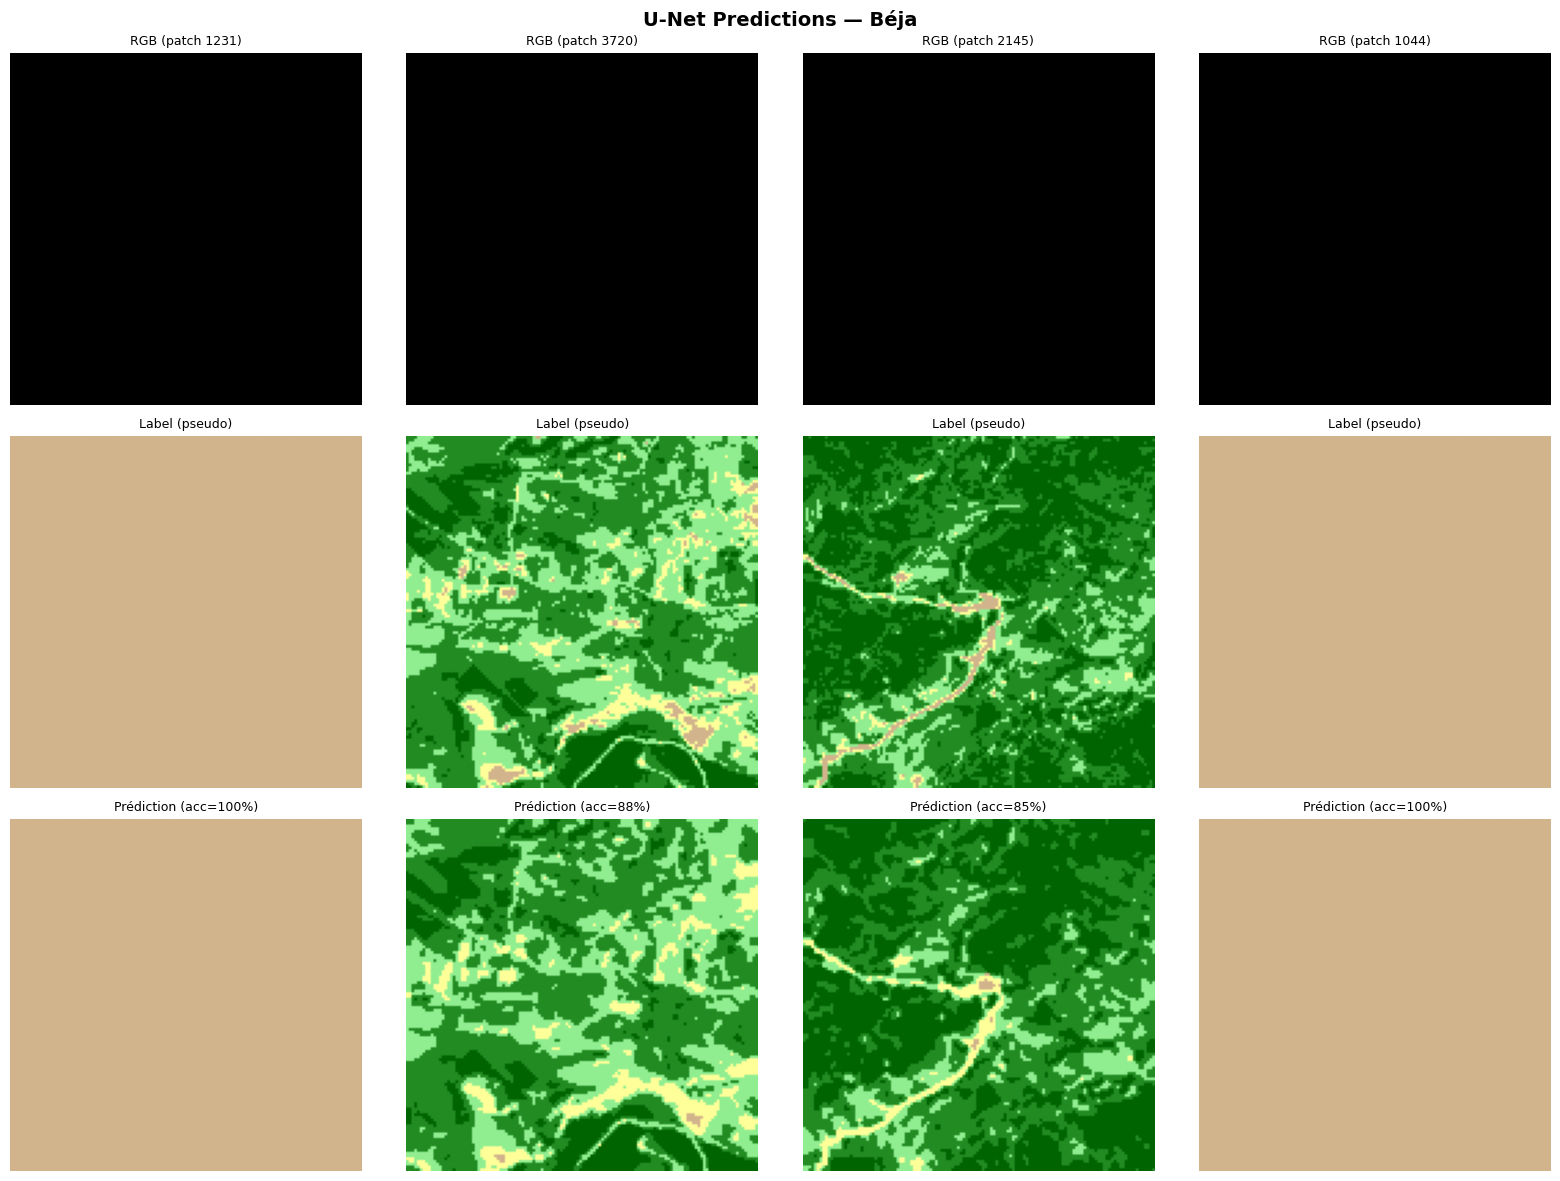

In [17]:
# Charger le meilleur modèle
checkpoint = torch.load(MODEL_DIR / 'best_unet_beja.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'✅ Meilleur modèle chargé (epoch {checkpoint["epoch"]}, val_loss={checkpoint["val_loss"]:.4f})')

from matplotlib.colors import ListedColormap
class_names  = ['Eau/Roche', 'Sol nu', 'Vég. sparse', 'Vég. mod.', 'Vég. dense', 'Très dense']
class_colors = ['#8B4513', '#D2B48C', '#FFFF99', '#90EE90', '#228B22', '#006400']
cmap = ListedColormap(class_colors)

# Visualiser 4 exemples (image RGB | label vrai | prédiction)
sample_val = np.random.choice(val_ids, size=4, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, pid in enumerate(sample_val):
    img_np = np.load(PATCHES_DIR / 'images' / f'patch_{pid:05d}.npy').astype(np.float32)
    lbl_np = np.load(PATCHES_DIR / 'labels' / f'patch_{pid:05d}.npy')

    # Prédiction
    with torch.no_grad():
        img_t = torch.from_numpy(img_np.transpose(2,0,1)).unsqueeze(0).to(device)
        pred = model(img_t).argmax(dim=1).squeeze(0).cpu().numpy()

    # RGB depuis bandes R,G,B
    rgb = img_np[:,:,[2,1,0]]
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

    axes[0, i].imshow(rgb)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'RGB (patch {pid})', fontsize=9)

    axes[1, i].imshow(lbl_np, cmap=cmap, vmin=0, vmax=5)
    axes[1, i].axis('off')
    axes[1, i].set_title('Label (pseudo)', fontsize=9)

    axes[2, i].imshow(pred, cmap=cmap, vmin=0, vmax=5)
    acc = (pred == lbl_np).mean() * 100
    axes[2, i].axis('off')
    axes[2, i].set_title(f'Prédiction (acc={acc:.0f}%)', fontsize=9)

plt.suptitle('U-Net Predictions — Béja', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'NB3_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ Part 8 : Résumé et prochaines étapes

Ce notebook a produit :
- `models/best_unet_beja.pth` — modèle U-Net entraîné (meilleur val_loss)
- `NB3_training_curves.png` — courbes loss/accuracy
- `NB3_predictions.png` — exemples visuels de prédictions

**→ Prêt pour NB4 : Inference sur l'image complète Béja**

In [18]:
print('=== RÉSUMÉ NB3 ===')
print(f'Architecture  : U-Net + MobileNetV2 encoder')
print(f'Paramètres    : {total_params:,}')
print(f'Epochs        : {len(history["train_loss"])} / {EPOCHS}')
print(f'Meilleur epoch: {checkpoint["epoch"]}')
print(f'Val loss      : {checkpoint["val_loss"]:.4f}')
print(f'Val accuracy  : {checkpoint["val_acc"]*100:.1f}%')
print(f'Modèle sauvé  : models/best_unet_beja.pth')
print('\n✅ NB3 terminé → lancer NB4_inference_export.ipynb')

=== RÉSUMÉ NB3 ===
Architecture  : U-Net + MobileNetV2 encoder
Paramètres    : 6,631,398
Epochs        : 20 / 20
Meilleur epoch: 15
Val loss      : 0.1957
Val accuracy  : 94.6%
Modèle sauvé  : models/best_unet_beja.pth

✅ NB3 terminé → lancer NB4_inference_export.ipynb
